In [1]:
import pandas as pd
import numpy as np
from itertools import combinations
from scipy.stats import mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests

def pval_to_star(p):
    if pd.isna(p): return ""
    if p < 0.0001: return "****"
    elif p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

# ---------------- Files ----------------
decon_file = "Decon-Results_Loy_COVID-MIS-C/merged_normalised_results.txt"
meta_file  = "GSE225221_cfrna_supplementary.tsv" 

# ---------------- Load decon ----------------
decon = pd.read_csv(decon_file, sep="\t", index_col=0)

# Bring sample id back as a column for merging
decon = decon.reset_index().rename(columns={"index": "sample_id"})

# ---------------- Load metadata ----------------
meta = pd.read_csv(meta_file, sep="\t")

meta_id_col = "cfrna_sample_id"
group_col   = "Diagnosis"     # pathology column
time_col    = "timepoint"     

# ---------------- Merge ----------------
merged = pd.merge(
    decon,
    meta,
    left_on="sample_id",
    right_on=meta_id_col,
    how="inner"
)

print(f"Matched unique samples: {merged[meta_id_col].nunique()}")
print(f"Matched rows (sample × tool): {merged.shape[0]}")

# ---------------- Keep 3 pathology categories ----------------
groups_to_keep = ["MIS-C", "COVID-19", "Control_Non-inflammatory"]
merged = merged[merged[group_col].isin(groups_to_keep)].copy()

# ---------------- Conditional timepoint filter ----------------
# Cases acute only; controls all timepoints
if time_col in merged.columns:
    mask_cases_acute  = merged[group_col].isin(["MIS-C", "COVID-19"]) & (merged[time_col] == "acute")
    mask_controls_all = merged[group_col].eq("Control_Non-inflammatory")
    merged = merged[mask_cases_acute | mask_controls_all].copy()

print("\nCounts after filters:")
print(merged[group_col].value_counts(dropna=False))

# ---------------- Identify tissue columns ----------------
exclude_cols = {"sample_id", meta_id_col, group_col, time_col, "DeconvolutionTool"}
tissue_cols = [c for c in merged.columns if c not in exclude_cols]

# Ensure numeric tissues
for c in tissue_cols:
    merged[c] = pd.to_numeric(merged[c], errors="coerce")

# ---------------- Long format ----------------
long_df = merged.melt(
    id_vars=["sample_id", "DeconvolutionTool", group_col],
    value_vars=tissue_cols,
    var_name="Tissue",
    value_name="Contribution"
).dropna(subset=["Contribution"])

# ---------------- Stats: overall KW + pairwise MWU ----------------
min_n_per_group = 2
results = []

for (tool, tissue), df_sub in long_df.groupby(["DeconvolutionTool", "Tissue"]):
    # arrays per pathology group
    arrays = {
        g: sub["Contribution"].values
        for g, sub in df_sub.groupby(group_col)
        if len(sub) >= min_n_per_group
    }
    present = sorted(arrays.keys())
    if len(present) < 2:
        continue

    # overall kruskal (if 3+ groups present)
    kw_p = np.nan
    if len(present) >= 3:
        try:
            kw_p = kruskal(*[arrays[g] for g in present]).pvalue
        except ValueError:
            kw_p = np.nan

    # pairwise MWU
    for g1, g2 in combinations(present, 2):
        v1, v2 = arrays[g1], arrays[g2]
        med1, med2 = np.median(v1), np.median(v2)
        delta = med2 - med1
        pval = mannwhitneyu(v1, v2, alternative="two-sided").pvalue

        direction = f"{g2} > {g1}" if delta > 0 else (f"{g1} > {g2}" if delta < 0 else "Equal medians")

        results.append({
            "DeconvolutionTool": tool,
            "Tissue": tissue,
            "Overall_Kruskal_p": kw_p,
            "Group1": g1,
            "Group2": g2,
            "pval": pval,
            "Median_Group1": med1,
            "Median_Group2": med2,
            "Delta_Group2_minus_Group1": delta,
            "Direction": direction,
            "n_Group1": len(v1),
            "n_Group2": len(v2),
        })

results_df = pd.DataFrame(results)

# ---------------- BH correction ----------------
# Pick: "global" or "within_tool"
BH_SCOPE = "within_tool"

results_df["pval_BH"] = np.nan

if BH_SCOPE == "global":
    valid = results_df["pval"].dropna()
    _, p_corr, _, _ = multipletests(valid, method="fdr_bh")
    results_df.loc[valid.index, "pval_BH"] = p_corr

elif BH_SCOPE == "within_tool":
    for tool, idx in results_df.groupby("DeconvolutionTool").groups.items():
        valid = results_df.loc[idx, "pval"].dropna()
        if len(valid) == 0:
            continue
        _, p_corr, _, _ = multipletests(valid, method="fdr_bh")
        results_df.loc[valid.index, "pval_BH"] = p_corr

results_df["Significant_BH"] = results_df["pval_BH"] < 0.05
results_df["Stars_BH"] = results_df["pval_BH"].apply(pval_to_star)

# ---------------- Save ----------------
results_df.to_csv("Pathology_3group_pairwise_tissue_stats_BH.csv", index=False)

sig_df = results_df[results_df["Significant_BH"]].sort_values("pval_BH")
sig_df.to_csv("Pathology_3group_significant_tissues_BH.csv", index=False)

print("\nTop significant hits:")
print(sig_df.head(20)[["DeconvolutionTool","Tissue","Group1","Group2","pval_BH","Stars_BH","Direction","Delta_Group2_minus_Group1"]])


Matched unique samples: 132
Matched rows (sample × tool): 924

Counts after filters:
Diagnosis
MIS-C                       392
COVID-19                    126
Control_Non-inflammatory     91
Name: count, dtype: int64

Top significant hits:
    DeconvolutionTool           Tissue                    Group1 Group2  \
26         BayesPrism        Esophagus  Control_Non-inflammatory  MIS-C   
35         BayesPrism      Fibroblasts  Control_Non-inflammatory  MIS-C   
299              NNLS  EsophagusMucosa  Control_Non-inflammatory  MIS-C   
320              NNLS      Lymphocytes  Control_Non-inflammatory  MIS-C   
347              NNLS           Spleen  Control_Non-inflammatory  MIS-C   
41         BayesPrism           Kidney  Control_Non-inflammatory  MIS-C   
194             MuSiC            Brain  Control_Non-inflammatory  MIS-C   
227             MuSiC             Lung  Control_Non-inflammatory  MIS-C   
221             MuSiC           Kidney  Control_Non-inflammatory  MIS-C   
209       


=== Significant comparisons (raw p < 0.05) ===
EsophagusMucosa | BayesPrism | Control_Non-inflammatory vs MIS-C                    | p=1.078e-05 **** | Δ=0.320 ↑
EsophagusMucosa | BayesPrism | COVID-19                 vs MIS-C                    | p=4.324e-03 **   | Δ=0.320 ↑
EsophagusMucosa | BayesPrism | COVID-19                 vs Control_Non-inflammatory | p=7.330e-03 **   | Δ=0.000 ↓
EsophagusMucosa | MuSiC      | Control_Non-inflammatory vs MIS-C                    | p=5.412e-08 **** | Δ=0.490 ↑
EsophagusMucosa | MuSiC      | COVID-19                 vs Control_Non-inflammatory | p=1.560e-04 ***  | Δ=-0.475 ↓
EsophagusMucosa | NNLS       | Control_Non-inflammatory vs MIS-C                    | p=3.767e-08 **** | Δ=1.255 ↑
EsophagusMucosa | NNLS       | COVID-19                 vs MIS-C                    | p=2.284e-05 **** | Δ=1.175 ↑
EsophagusMucosa | NNLS       | COVID-19                 vs Control_Non-inflammatory | p=4.067e-04 ***  | Δ=-0.080 ↓
EsophagusMucosa | QP         |

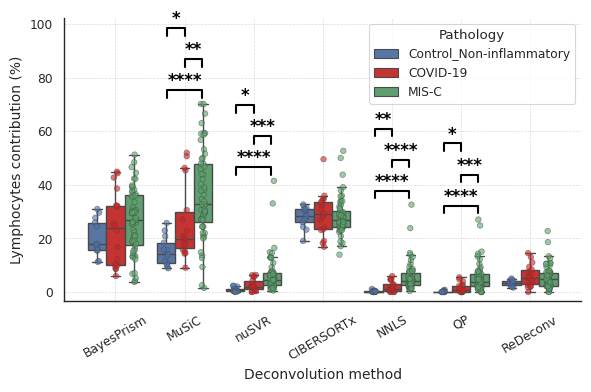

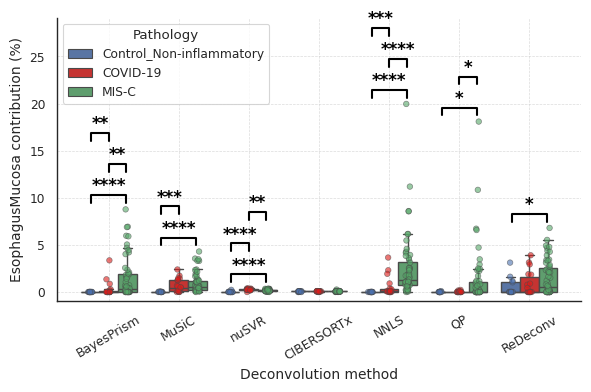

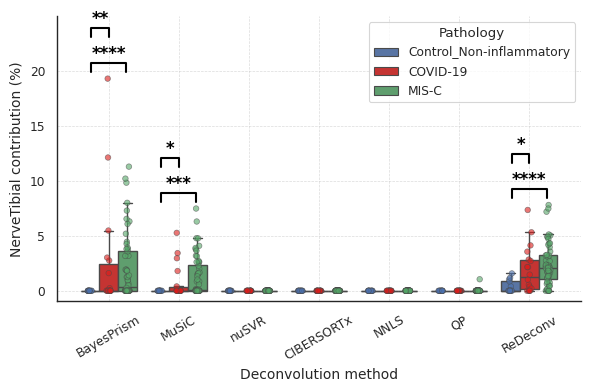

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']


# ---------------- Settings ----------------
tissues = ['Lymphocytes', 'EsophagusMucosa', 'NerveTibial']

method_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
path_order   = ["Control_Non-inflammatory", "COVID-19", "MIS-C"]

palette = {
    "Control_Non-inflammatory": "#4C72B0",  # blue
    "COVID-19": "#DD1C1A",                  # red
    "MIS-C": "#55A868"                      # green
}

alpha_sig = 0.05

def pval_to_star(p):
    if p < 0.0001: return "****"
    elif p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

def add_bracket(ax, x1, x2, y, text, height):
    ax.plot([x1, x1, x2, x2], [y, y+height, y+height, y], lw=1.5, c="black")
    ax.text((x1+x2)/2, y+height, text, ha="center", va="bottom",
            fontsize=12, fontweight="bold", color="black")

# ---------------- 1) Print significant comparisons (raw pval) ----------------
# results_df expected columns:
# ["DeconvolutionTool","Tissue","Group1","Group2","pval", ...]
sig = results_df[
    results_df["Tissue"].isin(tissues) &
    results_df["DeconvolutionTool"].isin(method_order) &
    (results_df["pval"] < alpha_sig)
].copy()

sig["Stars"] = sig["pval"].apply(pval_to_star)

print(f"\n=== Significant comparisons (raw p < {alpha_sig}) ===")
if sig.empty:
    print("None.")
else:
    sig = sig.sort_values(["Tissue", "DeconvolutionTool", "pval"])
    for _, r in sig.iterrows():
        arrow = "↑" if r.get("Delta_Group2_minus_Group1", 0) > 0 else "↓"
        delta_txt = ""
        if "Delta_Group2_minus_Group1" in r:
            delta_txt = f" | Δ={r['Delta_Group2_minus_Group1']:.3f} {arrow}"
        print(
            f"{r['Tissue']:12s} | {r['DeconvolutionTool']:10s} | "
            f"{r['Group1']:24s} vs {r['Group2']:24s} | "
            f"p={r['pval']:.3e} {r['Stars']:4s}{delta_txt}"
        )

# ---------------- 2) Plots: one figure per tissue, box + jitter + brackets ----------------
# long_df expected columns:
# ["sample_id","DeconvolutionTool","Diagnosis","Tissue","Contribution"]

sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.0)

# Offsets that match seaborn's dodge positions for 3 hues (approx)
# (good enough for bracket placement)
hue_offsets = {
    path_order[0]: -0.25,
    path_order[1]:  0.00,
    path_order[2]:  0.25
}

for tissue in tissues:
    df_t = long_df[
        (long_df["Tissue"] == tissue) &
        (long_df["DeconvolutionTool"].isin(method_order)) &
        (long_df["Diagnosis"].isin(path_order))
    ].copy()

    df_t["DeconvolutionTool"] = pd.Categorical(df_t["DeconvolutionTool"], categories=method_order, ordered=True)
    df_t["Diagnosis"] = pd.Categorical(df_t["Diagnosis"], categories=path_order, ordered=True)

    plt.figure(figsize=(6, 4))
    ax = sns.boxplot(
        data=df_t,
        x="DeconvolutionTool",
        y="Contribution",
        hue="Diagnosis",
        hue_order=path_order,
        order=method_order,
        palette=palette,
        dodge=True,
        showfliers=False
    )

    sns.stripplot(
        data=df_t,
        x="DeconvolutionTool",
        y="Contribution",
        hue="Diagnosis",
        hue_order=path_order,
        order=method_order,
        palette=palette,
        dodge=True,
        jitter=True,
        alpha=0.6,
        linewidth=0.5,
        size=4,
        ax=ax
    )

    # keep a single legend (3 entries)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:3],
        labels[:3],
        title="Pathology",
        frameon=True
    #    bbox_to_anchor=(1.02, 0.5),   # outside, right
    #    loc="center left"
    )
    
    # Aesthetic like the ALT plot
    #ax.set_title(tissue, fontsize=16, fontweight="bold")
    ax.set_xlabel("Deconvolution method", fontsize=10)
    ax.set_ylabel(f"{tissue} contribution (%)", fontsize=10)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    sns.despine()
    ax.tick_params(axis="x", rotation=30)

    # ---- Add brackets for significant comparisons only (raw pval) ----
    sig_t = sig[sig["Tissue"] == tissue].copy()
    if not sig_t.empty:
        # Use axis range to define consistent spacing in DATA units
        y0, y1 = ax.get_ylim()
        yr = max(y1 - y0, 1e-6)
        step = 0.15 * yr          # vertical gap between bracket levels
        height = 0.25 * step      # bracket "tick" height
        pad = 0.03 * yr           # padding above the data for that method

        # x positions for each method
        xticks = ax.get_xticks()
        xticklabels = [t.get_text() for t in ax.get_xticklabels()]
        tool_to_x = dict(zip(xticklabels, xticks))

        # track how many brackets already drawn per method (stacking)
        stack_count = {m: 0 for m in method_order}

        # track the highest y used per method so we can expand ylim later
        tool_top_y = {m: -np.inf for m in method_order}

        for _, r in sig_t.sort_values("pval").iterrows():
            tool = r["DeconvolutionTool"]
            g1, g2 = r["Group1"], r["Group2"]
            if tool not in tool_to_x or g1 not in hue_offsets or g2 not in hue_offsets:
                continue

            # method-local top of the data
            tool_ymax = df_t.loc[df_t["DeconvolutionTool"] == tool, "Contribution"].max()
            if not np.isfinite(tool_ymax):
                tool_ymax = 0.0

            # y position for this bracket = local ymax + padding + stacked steps
            level = stack_count[tool]
            y = tool_ymax + pad + level * step

            x_center = tool_to_x[tool]
            x1 = x_center + hue_offsets[g1]
            x2 = x_center + hue_offsets[g2]
            if x2 < x1:
                x1, x2 = x2, x1

            add_bracket(ax, x1, x2, y, pval_to_star(r["pval"]), height=height)

            stack_count[tool] += 1
            tool_top_y[tool] = max(tool_top_y[tool], y + height)

        # Expand y-limit enough for the highest bracket among all methods
        global_top = max([v for v in tool_top_y.values() if np.isfinite(v)] + [y1])
        ax.set_ylim(y0, max(y1, global_top + 0.05 * yr))


    plt.tight_layout()
    plt.savefig(f"{tissue}_Contribution_by_Pathology.svg", format="svg", bbox_inches="tight")
    plt.show()
    plt.close()
